## Dual Support Vector Machine

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, clear_output

In [22]:
def svm(X, T, kernel_f, kernelName, rho, steps_per_display=10, steps=1000):

    # Initialize kernel values
    N = X.shape[0]
    K = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            K[i, j] = kernel_f(X[i, :], X[j, :])
 
    # Initialize alpha values to 0.5
    alpha = np.array([0.5] * N).reshape((-1, 1))
    
    # history vectors for plotting
    Lds = np.zeros(steps)
    nalphas = np.zeros(steps)

    for reps in range(steps):
        
        dLddak = 1 - T * (alpha.T @ (T * K)).T
        alpha += rho/N * dLddak

        alpha -= rho/N * (alpha.T @ T) * T
        
        # Enforce constraint that all alphas are >= 0
        alpha[alpha < 0] = 0

        # When 100th rep is reached, update graphics less often
        if reps == 200:
            steps_per_display *= 100

        TT = T @ T.T
        aa = alpha @ alpha.T
        s = np.sum(aa * TT * K)
        Ld = np.sum(alpha) - 0.5 * s
        Lds[reps] = Ld
        nalphas[reps] = np.sum(alpha > 0)

        # From here to end is all for graphic display
        if (reps + 1) % steps_per_display == 0:
            
            # Make discriminant function
            i = np.where(alpha > 0)[0][0]  #first nonzero alpha
            #betazero = 1 / T[i] - (alpha * T).T @ K[:, i]
            betazero =  T[i] - (alpha * T).T @ K[:, i]
            
            def disc_f(x):
                Kdisc = np.zeros((x.shape[0] ,N))
                for j in range(x.shape[0]):
                    for i in range(N):
                        Kdisc[j, i] = kernel_f(x[j: j+1,:], X[i, :])
                return Kdisc @ (T * alpha) + betazero

            xs = np.linspace(np.min(X), np.max(X), 10)
            Xs, Ys = np.meshgrid(xs, xs)
            points = np.vstack((Xs.flat, Ys.flat)).T
            d = disc_f(points)
            d.resize(Xs.shape)
            
            fig.clf()

            plt.subplot(2, 1, 1)
            plt.contourf(Xs, Ys, d, [-np.inf, 0, np.inf], colors=["red", "blue"], alpha=0.3)
            mask = alpha > 0
            # plot support vectors in yellow
            rows = mask.flatten()
            plt.plot(X[rows, 0], X[rows, 1], 'o', color='yellow', ms=10)
            colors = ["red", "blue"]  # by class
            mask = (T < 0).ravel()
            plt.plot(X[mask, 0], X[mask, 1], '.', color=colors[0])
            mask = (T > 0).ravel()
            plt.plot(X[mask, 0], X[mask, 1], '.', color=colors[1])
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.title(kernelName)
            

            plt.subplot(2, 1, 2)
            plt.plot(nalphas[:reps])
            plt.xlabel("Steps")
            plt.ylabel("Num support vectors")
            plt.ylim(0, N + 2)
            
            plt.tight_layout()
            
            clear_output(wait=True)
            display(fig)
    
    clear_output(wait=True)

In [23]:
m1 = np.array([-1, -2])
m2 = np.array([2, 3])

m3 = np.array([-2, 4]) * 2
m4 = np.array([3, 0]) * 2

nTrain = 200

X1 = np.vstack(( np.random.normal(0, 1, (nTrain, 2)) + m1,
                 np.random.normal(0, 1, (nTrain, 2)) + m2))
X2 = np.vstack(( np.random.normal(0, 1, (nTrain, 2)) + m3,
                 np.random.normal(0, 1, (nTrain, 2)) + m4))
X = np.vstack((X1, X2))
T = np.array([-1] * nTrain * 2 + [1] * nTrain * 2).reshape((-1, 1))

X.shape, T.shape

((800, 2), (800, 1))

In [24]:
### Kernels
def kernel_gaussian(xi, xj):
    return np.exp(-np.sum((xi - xj)**2) / 20.0)

def kernel_linear(xi, xj):
    return np.dot(xi, xj)

def kernel_poly(xi, xj):
    degree = 4
    return (1 + np.dot(xi, xj)) ** degree
    
funcs = [kernel_linear, kernel_poly, kernel_gaussian]
kernel_names = ['Linear Kernel', 'Degree 4 Polynomial Kernel', 'Gaussian Kernel']
rhos = [0.05, 1.e-7, 1.0]

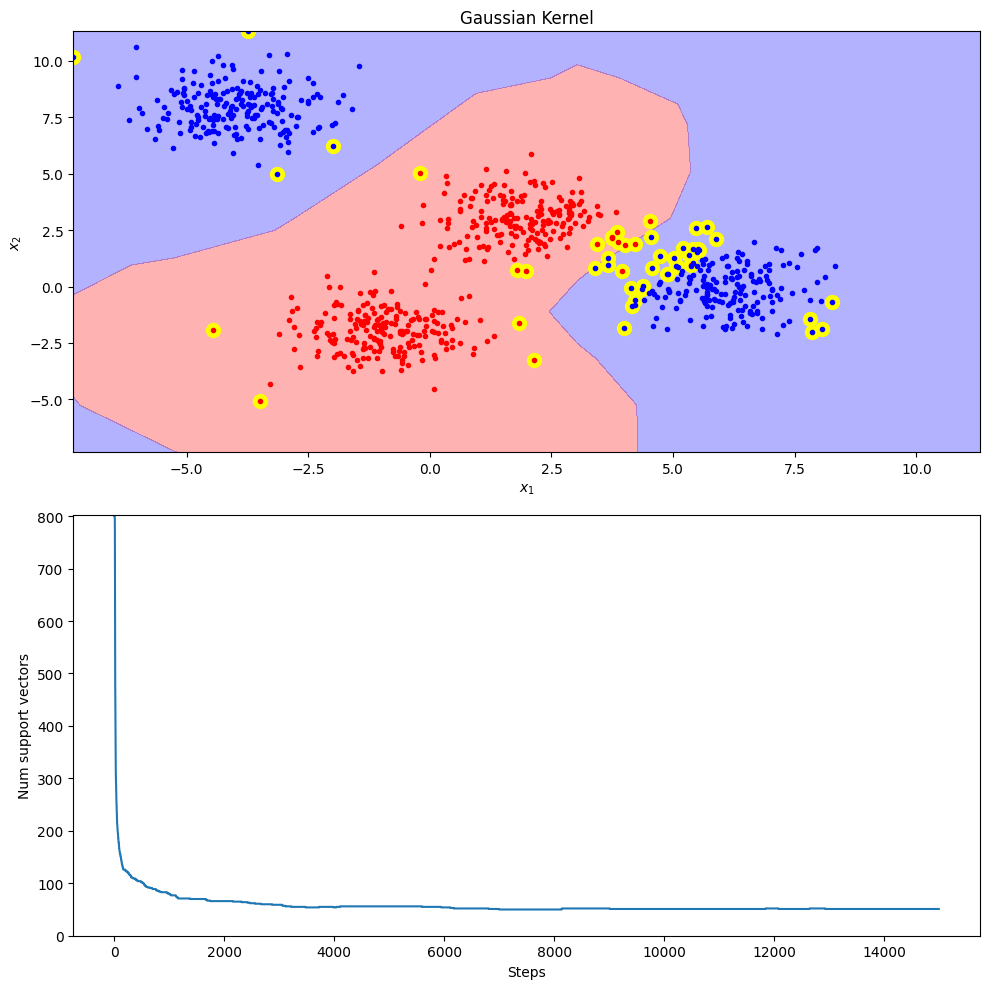

In [25]:
kerneli = 2

kernel_name = kernel_names[kerneli]
print("using kernel", kernel_name)

fig = plt.figure(figsize=(10, 10))

svm(X, T, funcs[kerneli], kernel_name, rhos[kerneli], steps_per_display=10, steps=15000)